# Лабораторная работа №1 «Знакомство с нейронными сетями»

**Цель работы:** ознакомление со структурой нейронных сетей. Получение навыка программирования нейронных сетей.

## Порядок выполнения работы

### 1. Создание схемы нейронной сети согласно варианту

Рассмотрим двухслойную нейронную сеть следующей структуры:
- **Входной слой:** 1 вход ($x$).
- **Скрытый слой (первый):** 5 нейронов, функция активации — пороговая.
- **Выходной слой (второй):** 1 нейрон, функция активации — линейная: $Y(S)=k\cdot S$.

Сеть полносвязная: единственный вход связан с каждым из пяти скрытых нейронов, а все пять скрытых нейронов связаны с единственным выходом.

**Схема нейронной сети:**

`x → [P1, P2, P3, P4, P5] → Y`

Каждый скрытый нейрон имеет собственный вес входной связи, а выходной нейрон — пять весов связей со скрытого слоя.

### 2. Создание математической модели нейронной сети согласно варианту

#### 1. Первый (скрытый) слой

Так как вход один, взвешенная сумма каждого скрытого нейрона равна произведению входного сигнала на вес соответствующей связи:

$$S_1^{(1)}=x\cdot w_{11}^{(1)},\quad P_1=H(S_1^{(1)})$$
$$S_2^{(1)}=x\cdot w_{21}^{(1)},\quad P_2=H(S_2^{(1)})$$
$$S_3^{(1)}=x\cdot w_{31}^{(1)},\quad P_3=H(S_3^{(1)})$$
$$S_4^{(1)}=x\cdot w_{41}^{(1)},\quad P_4=H(S_4^{(1)})$$
$$S_5^{(1)}=x\cdot w_{51}^{(1)},\quad P_5=H(S_5^{(1)})$$

Пороговая функция активации с порогом 0:

$$H(S)=\begin{cases}1,&S\geq 0,\\0,&S<0.\end{cases}$$

Обобщённая формула:

$$S_j^{(1)}=\sum_{i=1}^{1}x_iw_{ji}^{(1)}=xw_{j1}^{(1)},\quad P_j=H(S_j^{(1)}),\quad j=1,\ldots,5.$$

#### 2. Второй (выходной) слой

Выходной нейрон вычисляет взвешенную сумму выходов скрытого слоя:

$$S_1^{(2)}=P_1w_{11}^{(2)}+P_2w_{12}^{(2)}+P_3w_{13}^{(2)}+P_4w_{14}^{(2)}+P_5w_{15}^{(2)}$$

Затем применяется линейная функция:

$$Y_1=k\cdot S_1^{(2)}.$$

В этой работе, как и в примере, используется коэффициент $k=5$. Обобщённая запись:

$$S_q^{(2)}=\sum_{j=1}^{5}P_jw_{qj}^{(2)},\quad Y_q=5S_q^{(2)},\quad q=1.$$

Здесь $w_{j1}^{(1)}$ — вес от входа к j-му скрытому нейрону, а $w_{1j}^{(2)}$ — вес от j-го скрытого нейрона к выходу. Смещения (bias) не добавляются, поскольку их нет в вычислительной модели исходного примера.

## 3. Моделирование нейронной сети (практическое задание)

Реализуем прямой проход сигнала через сеть. Функция `Neuron` рассчитывает значения скрытых и выходного слоёв, а `Wes` запускает моделирование с тремя диапазонами случайных весов:
- $[0;b]$ — положительные веса;
- $[a;0]$ — отрицательные веса;
- $[a;b]$ — смешанные веса.

Для соответствия варианту матрица весов первого слоя имеет размер `(5, 1)`, второго слоя — `(1, 5)`.

### 3.1. Реализация модели нейронной сети

В `Xx` хранится один входной сигнал для каждого временного шага, поэтому его размер — `(1, T)`. `WS` хранит пять входных весов, `WV` — пять весов выходного нейрона. В скрытом слое используется пороговая функция, а на выходе — линейная функция с коэффициентом 5.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Диапазоны весов (базовый случай)
a = -1
b = 1
k = 5

In [2]:
def Neuron(WS, WV, Xx, vx, weight_label=""):
    """
    Прямой проход двухслойной сети:
    Xx: (1, T)   один входной сигнал на T шагах времени
    WS: (5, 1)   веса от входа к пяти скрытым нейронам
    WV: (1, 5)   веса от пяти скрытых нейронов к одному выходу
    """
    Y = np.zeros(1)
    S = np.zeros(5)
    P = np.zeros(5)
    s = np.zeros(1)
    y = np.zeros((1, Xx.shape[1]))

    for t in range(0, Xx.shape[1]):
        Y = np.zeros(1)
        S = np.zeros(5)
        P = np.zeros(5)
        s = np.zeros(1)

        # Скрытый слой: взвешенная сумма и пороговая активация
        for i in range(0, 5):
            for j in range(0, 1):
                S[i] = Xx[j, t] * WS[i, j] + S[i]
            P[i] = 1 if S[i] >= 0 else 0

        # Выходной слой: взвешенная сумма и линейная активация
        for i in range(0, 1):
            for j in range(0, 5):
                s[i] = P[j] * WV[i, j] + s[i]
            Y[i] = k * s[i]
            y[i, t] = Y[i]

    # График единственного выхода сети
    plt.figure(figsize=(10, 6))
    plt.grid(alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(f'Выход нейронной сети | {weight_label}', fontsize=13, fontweight='bold')
    plt.plot(vx, y[0], linewidth=2, label='Y1', marker='o', markersize=4)
    plt.legend(fontsize=11)
    plt.tight_layout()
    return y

In [3]:
def Wes(Xx, vx, a, b):
    # [0, b] — только положительные веса
    WS = np.random.uniform(0, b, (5, 1))
    WV = np.random.uniform(0, b, (1, 5))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [0, {b}]")

    # [a, 0] — только отрицательные веса
    WS = np.random.uniform(a, 0, (5, 1))
    WV = np.random.uniform(a, 0, (1, 5))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, 0]")

    # [a, b] — смешанные веса
    WS = np.random.uniform(a, b, (5, 1))
    WV = np.random.uniform(a, b, (1, 5))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, {b}]")

### 3.2. Подготовка и визуализация входных данных

В исходном примере использовались три входа, на которые подавались линейный, пороговый и синусоидальный сигналы. В данном варианте вход только один, поэтому эти сигналы рассматриваются **по отдельности** как три тестовых воздействия на один и тот же вход сети.

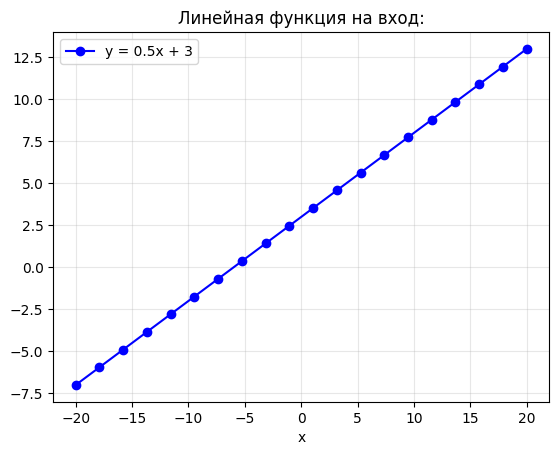

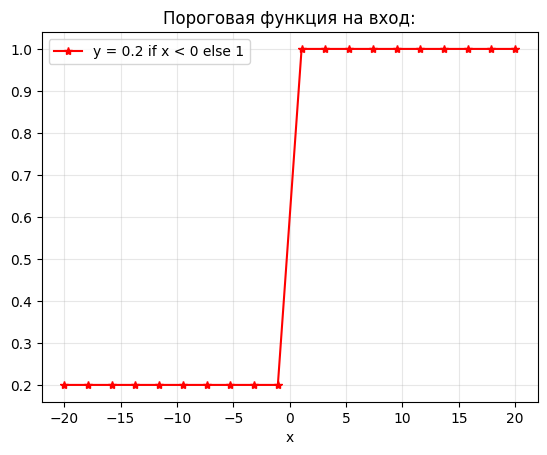

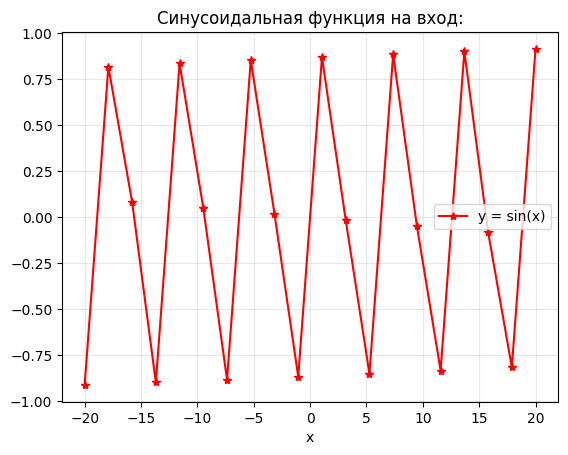

In [4]:
# Временная ось и три тестовых сигнала для единственного входа
vx = np.linspace(-20, 20, 20)
X_linear = (1, vx * 0.5 + 3)
X_threshold = (1, np.where(vx < 0, 0.2, 1.0))
X_sin = (1, np.sin(vx))

X_linear = np.array([X_linear[1]])
X_threshold = np.array([X_threshold[1]])
X_sin = np.array([X_sin[1]])

plt.figure()
plt.title('Линейная функция на вход:')
plt.plot(vx, X_linear[0], 'bo-', label='y = 0.5x + 3')
plt.xlabel('x')
plt.grid(alpha=0.3)
plt.legend()

plt.figure()
plt.title('Пороговая функция на вход:')
plt.plot(vx, X_threshold[0], 'r*-', label='y = 0.2 if x < 0 else 1')
plt.xlabel('x')
plt.grid(alpha=0.3)
plt.legend()

plt.figure()
plt.title('Синусоидальная функция на вход:')
plt.plot(vx, X_sin[0], 'r*-', label='y = sin(x)')
plt.xlabel('x')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 3.3. Эксперименты с весами

Для каждого из трёх тестовых сигналов выполним одинаковую серию опытов: с базовыми весами, с весами, уменьшенными в 10 раз, и с весами, увеличенными в 10 раз. В каждом опыте `Wes` строит по три графика — для положительных, отрицательных и смешанных весов.

#### 3.3.1. Базовый эксперимент

Запустим моделирование для диапазонов весов от -1 до 1.

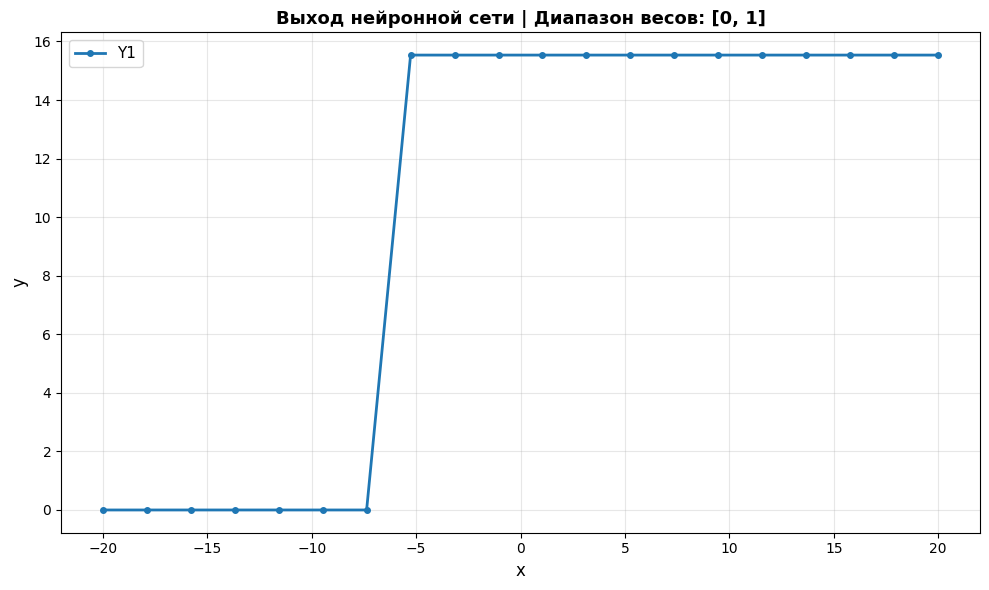

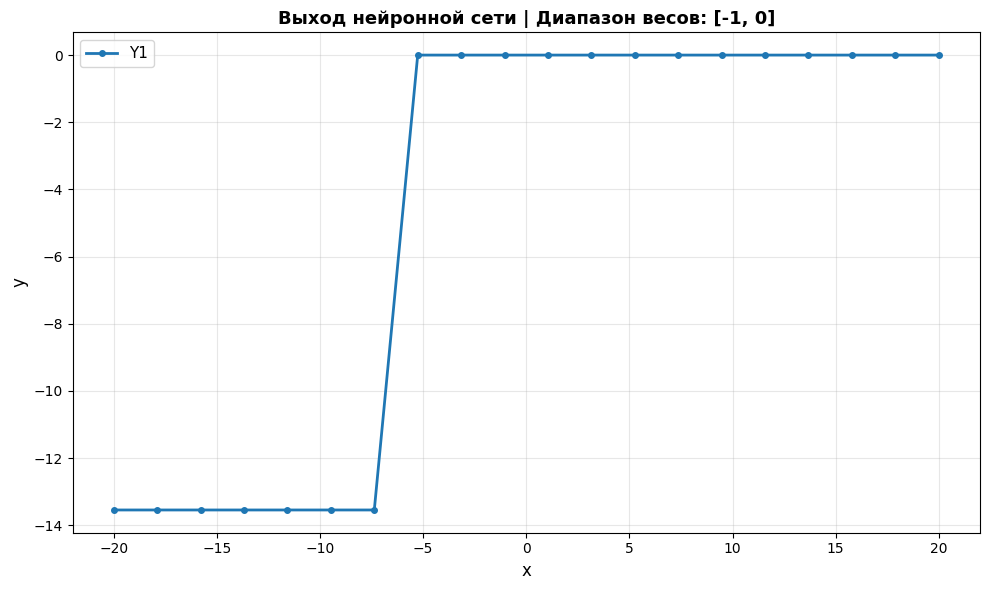

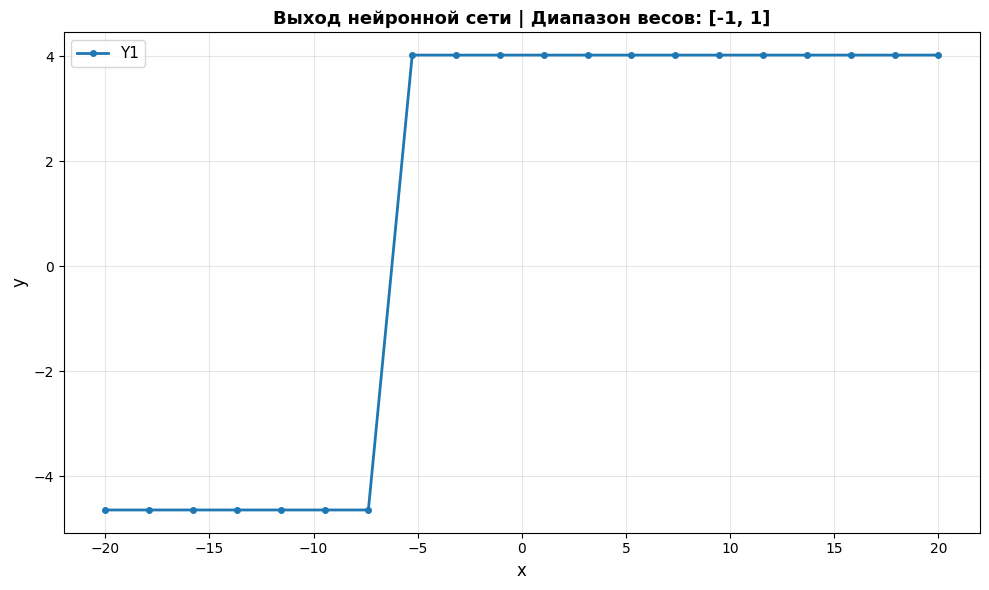

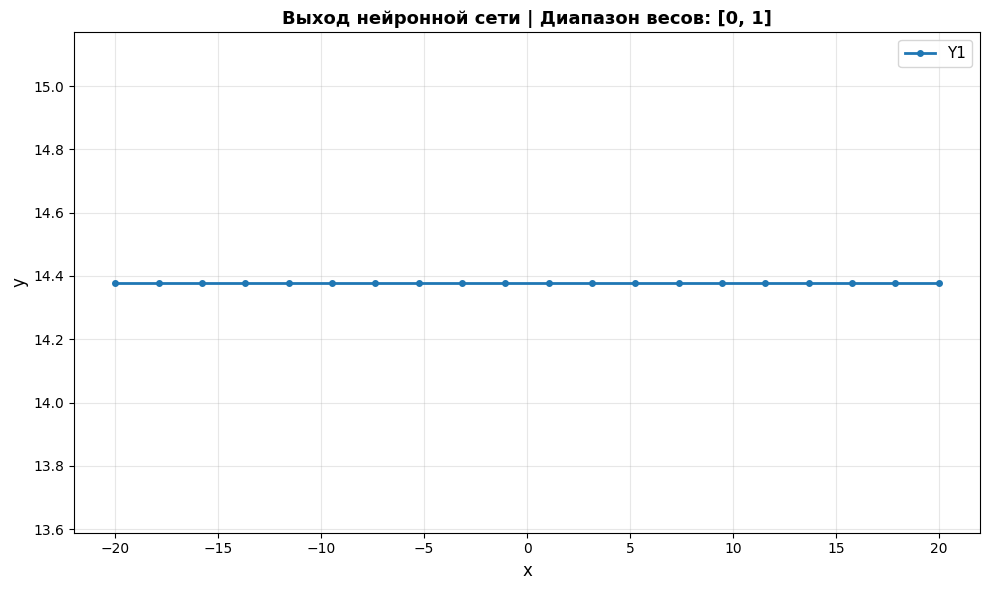

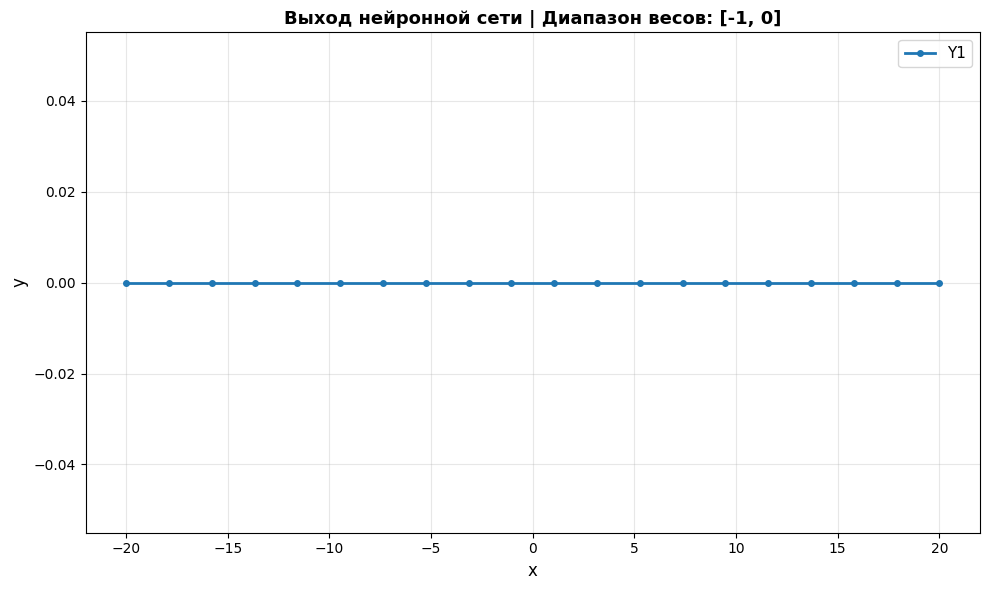

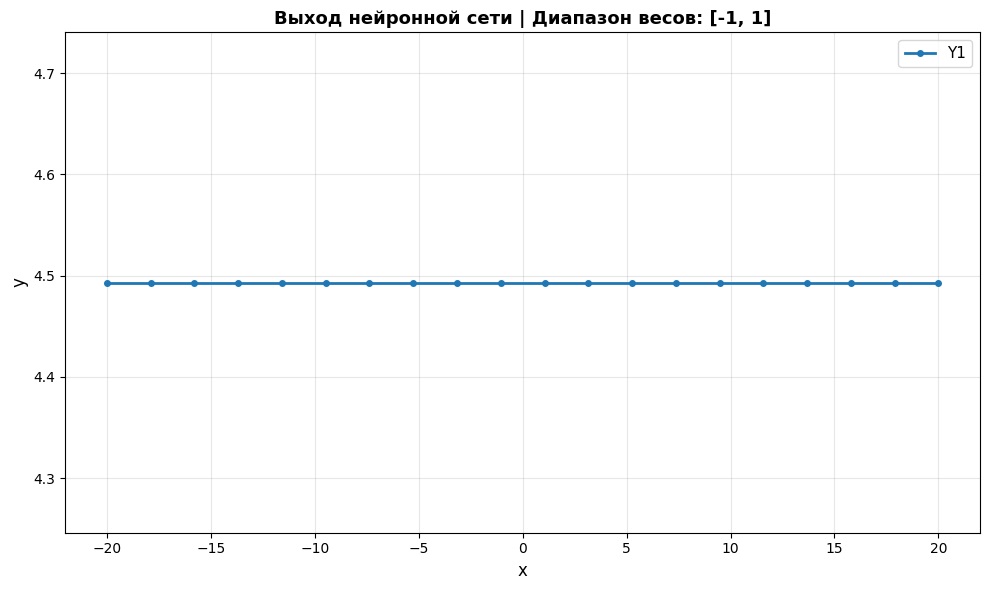

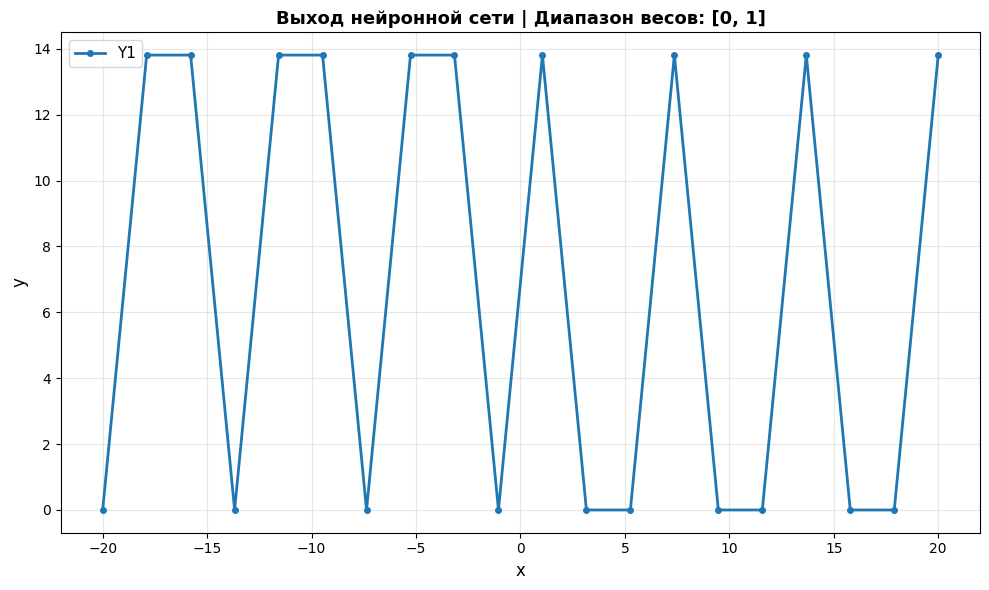

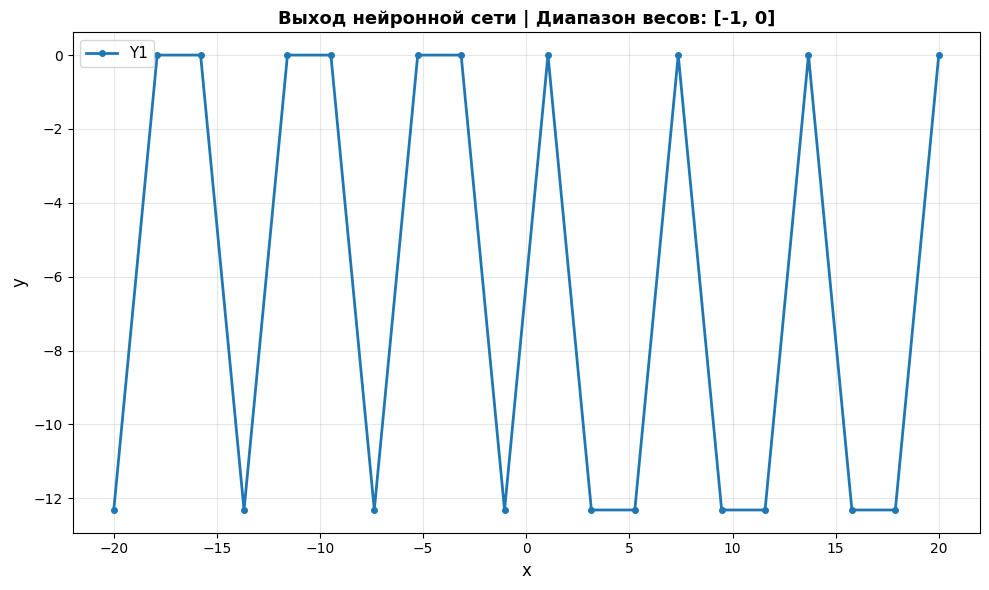

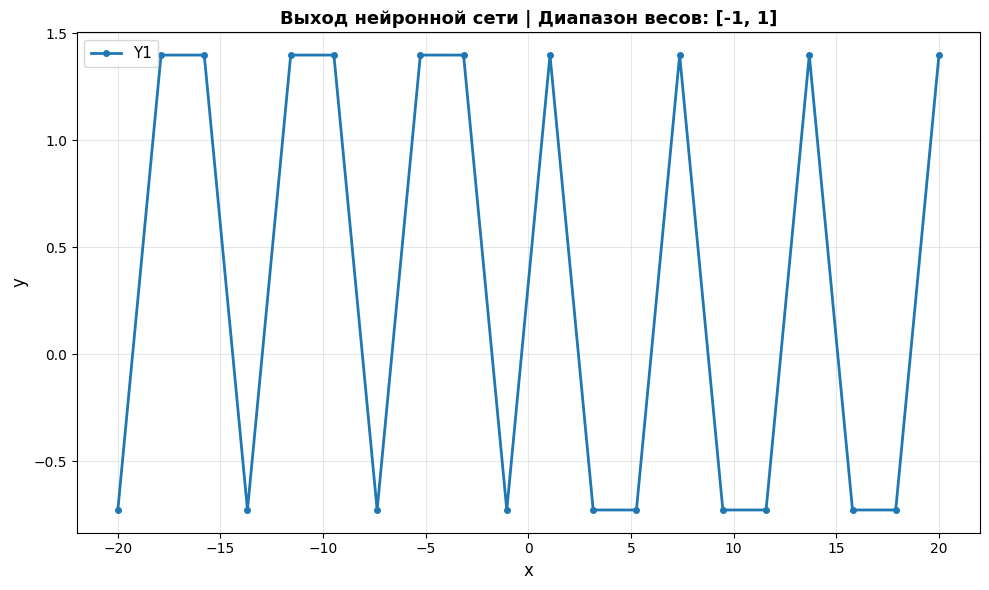

In [5]:
# Линейный сигнал
Wes(X_linear, vx, -1, 1)
plt.show()

# Пороговый сигнал
Wes(X_threshold, vx, -1, 1)
plt.show()

# Синусоидальный сигнал
Wes(X_sin, vx, -1, 1)
plt.show()

**Вывод:** характер выхода зависит от знака случайных весов и от входного сигнала. Пороговая функция скрытого слоя преобразует взвешенные значения в 0 или 1, поэтому выход сети изменяется ступенчато. Линейный выходной слой формирует итоговое значение как взвешенную сумму активных скрытых нейронов.

#### 3.3.2. Эксперимент с уменьшением весов в 10 раз

Проверим диапазоны $[-0.1;0]$, $[-0.1;0.1]$ и $[0;0.1]$.

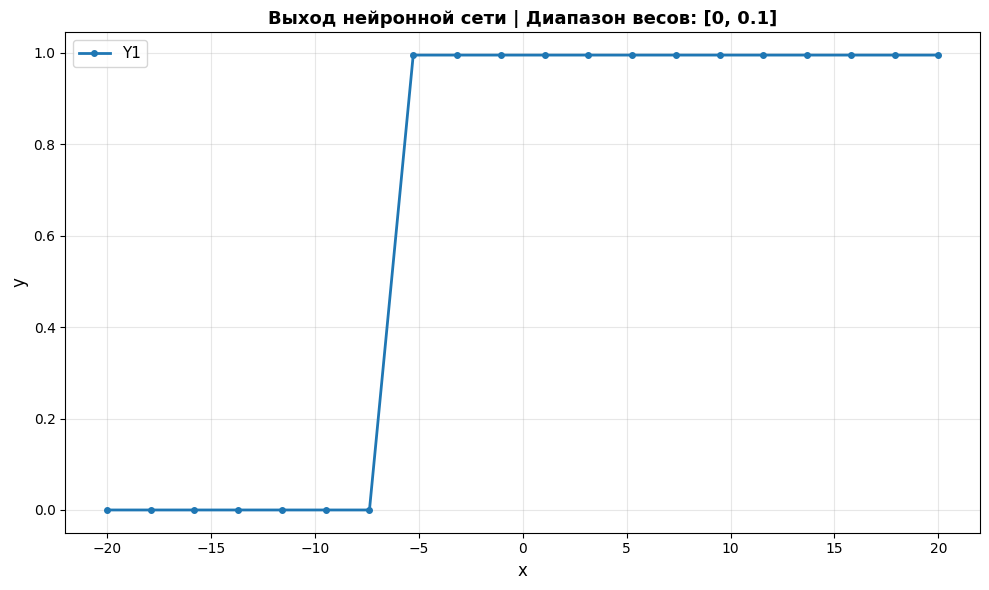

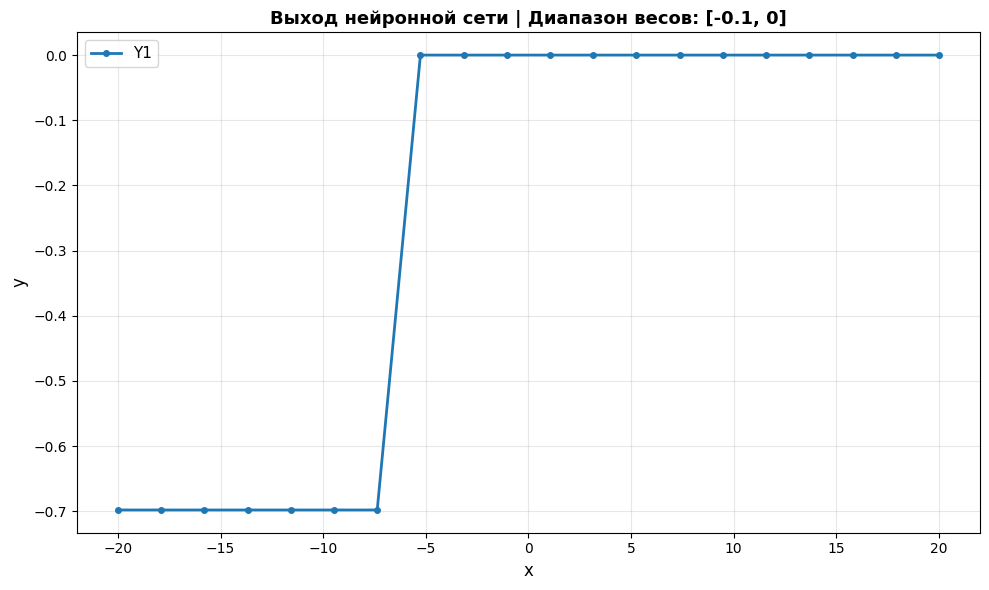

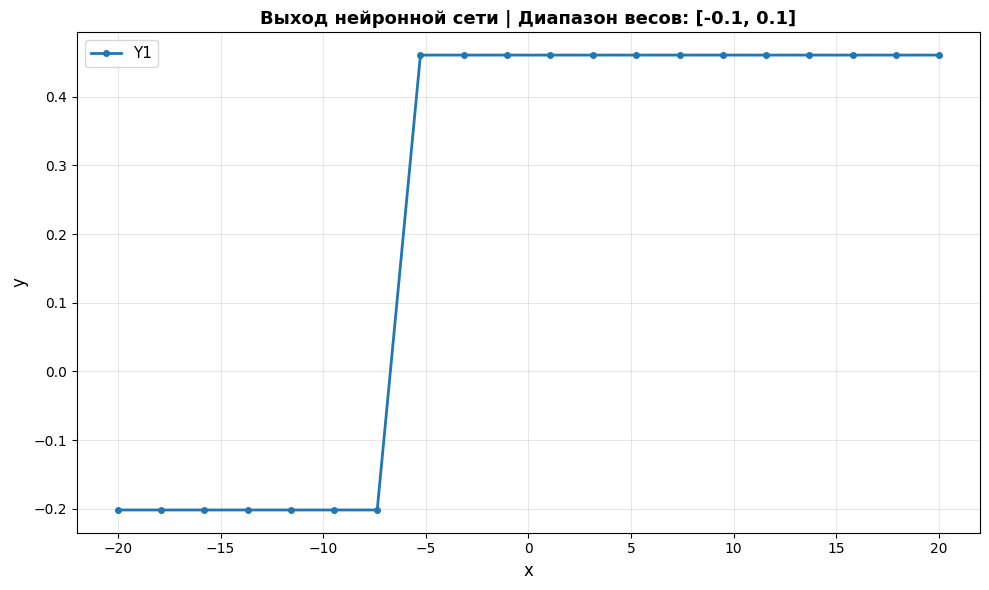

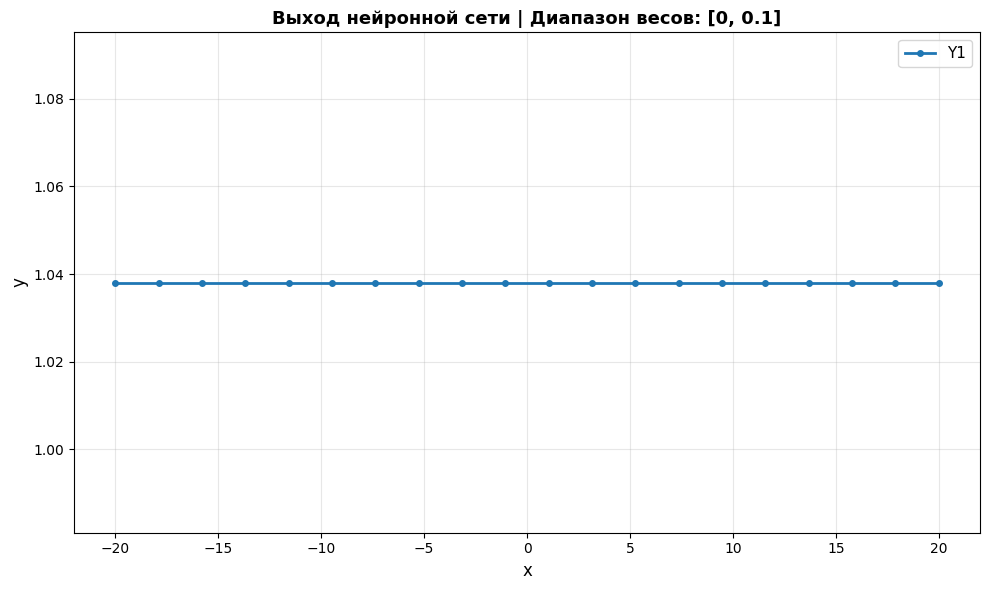

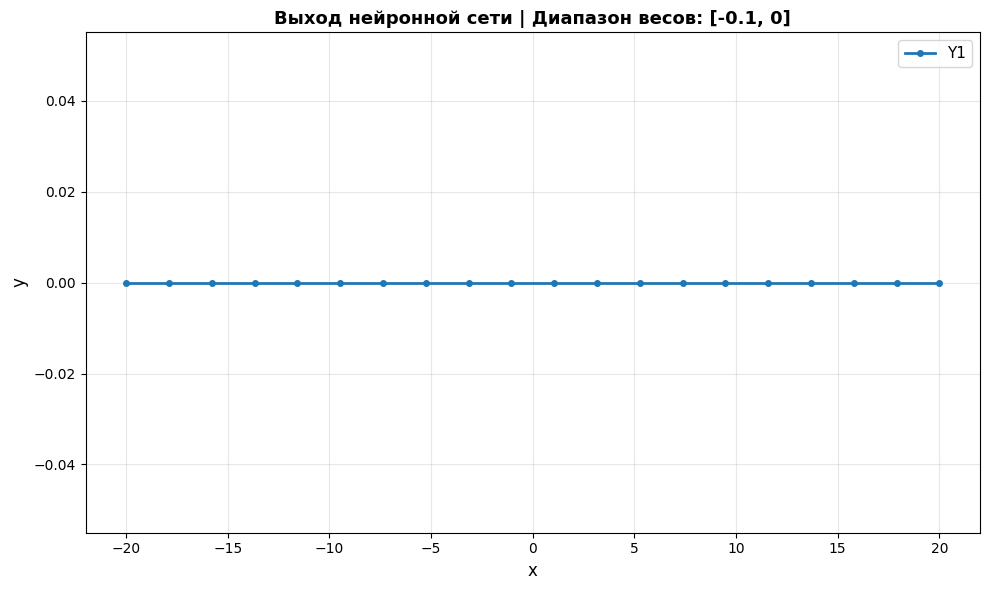

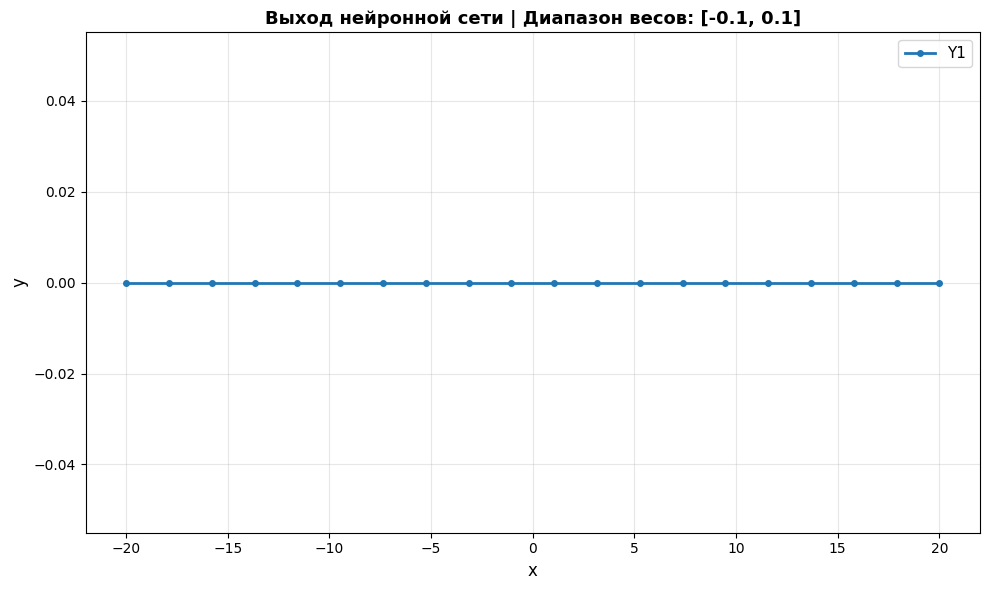

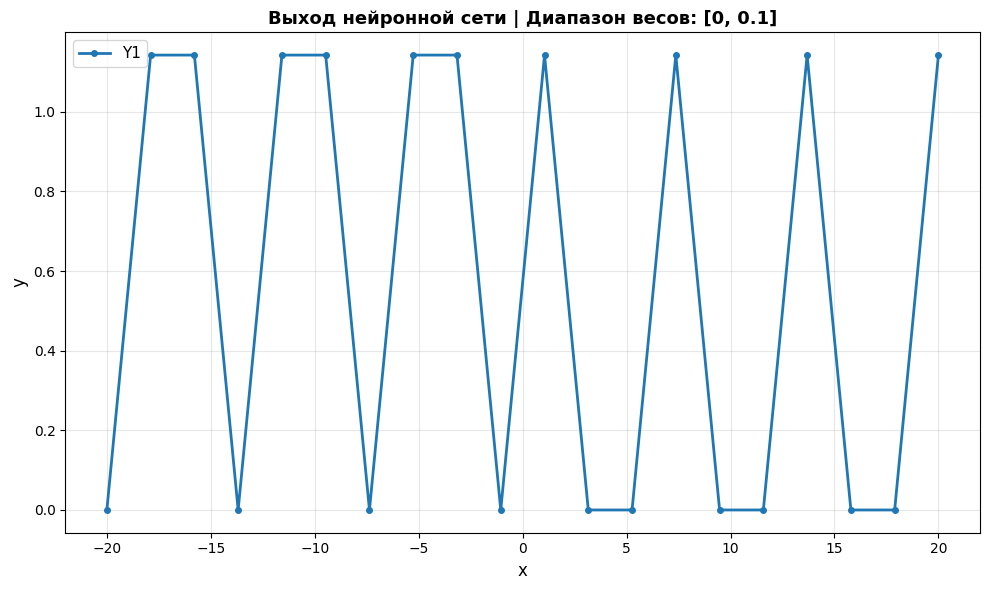

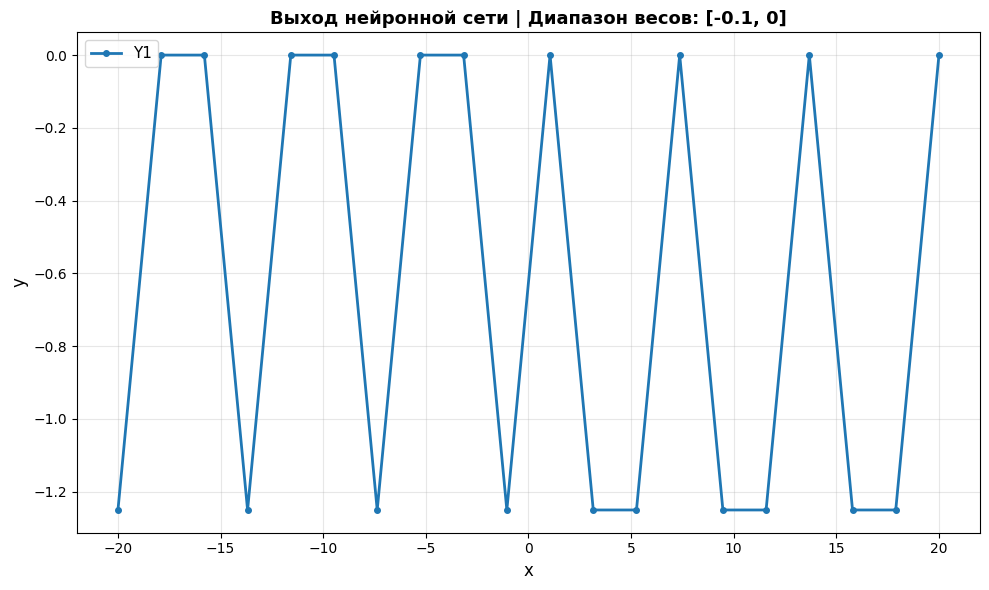

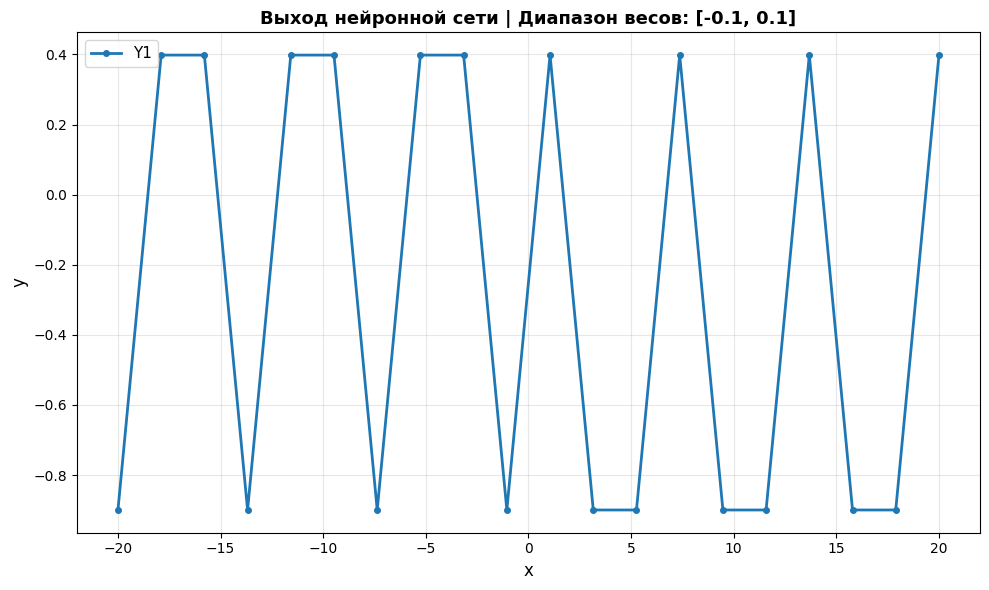

In [6]:
# Линейный сигнал
Wes(X_linear, vx, -0.1, 0.1)
plt.show()

# Пороговый сигнал
Wes(X_threshold, vx, -0.1, 0.1)
plt.show()

# Синусоидальный сигнал
Wes(X_sin, vx, -0.1, 0.1)
plt.show()

**Вывод:** уменьшение весов выходного слоя уменьшает типичный масштаб выходного сигнала. Однако пороговая активация скрытого слоя по-прежнему выдаёт только 0 или 1. При нулевом пороге и отсутствии смещений уменьшение ненулевых входных весов не сдвигает точку переключения, но сохраняет зависимость активации от знака произведения входа и веса.

#### 3.3.3. Эксперимент с увеличением весов в 10 раз

Проверим диапазоны $[-10;0]$, $[-10;10]$ и $[0;10]$.

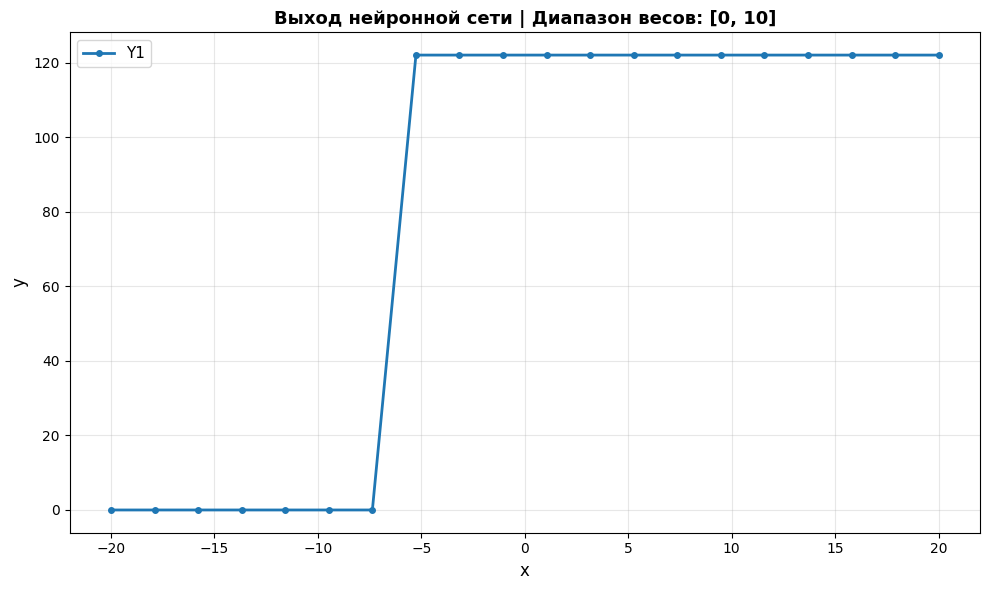

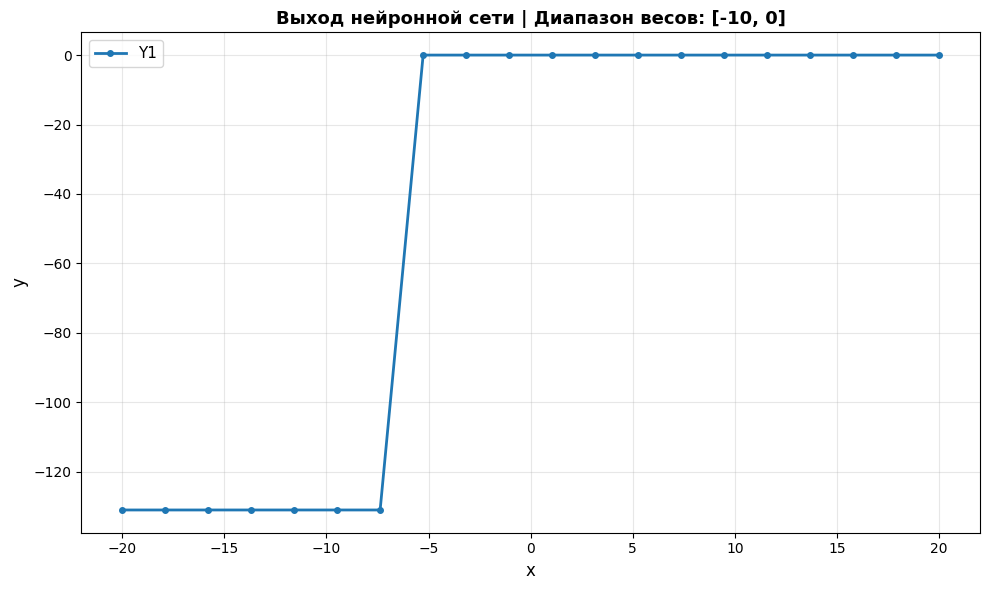

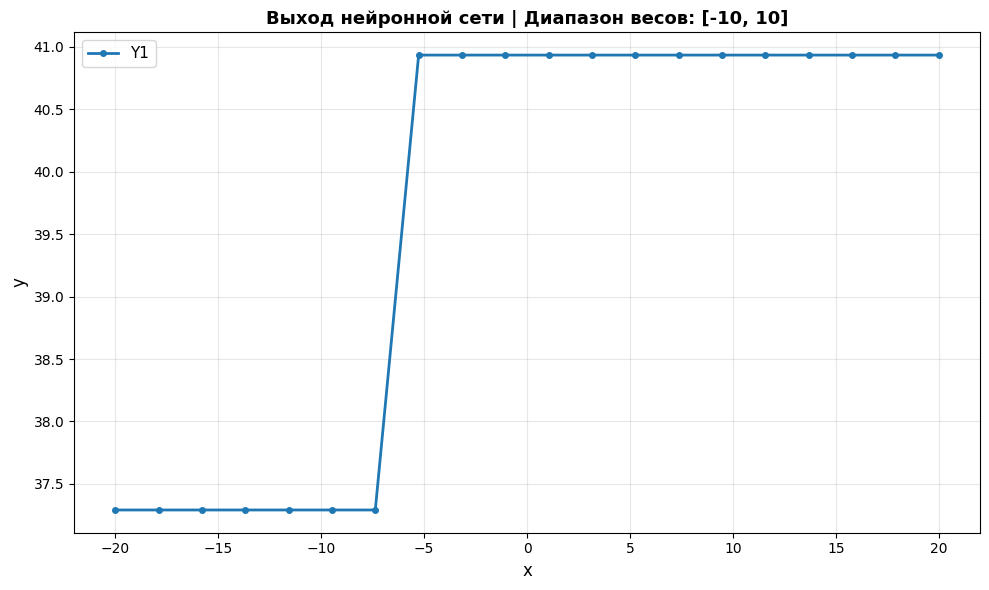

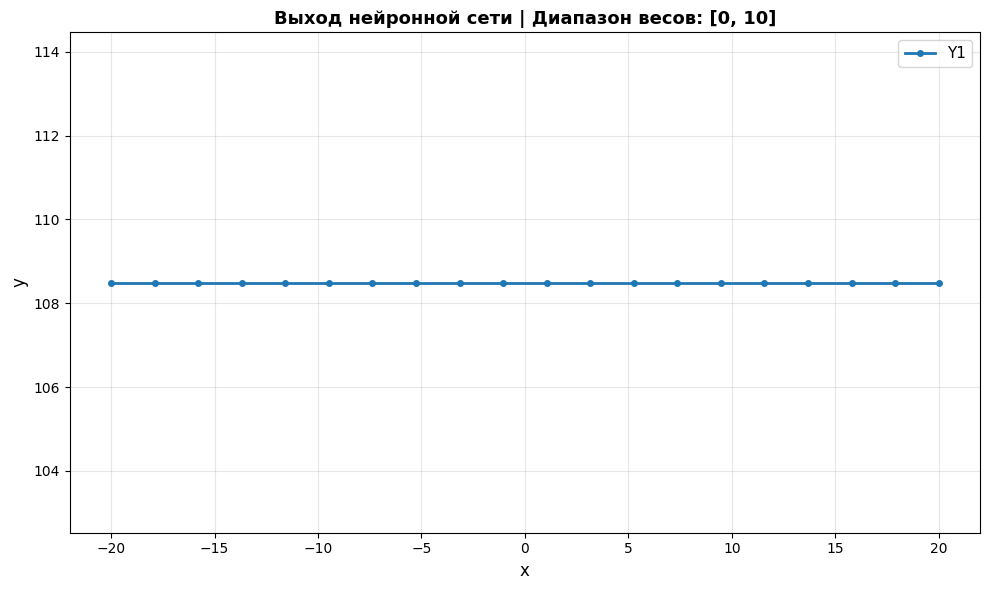

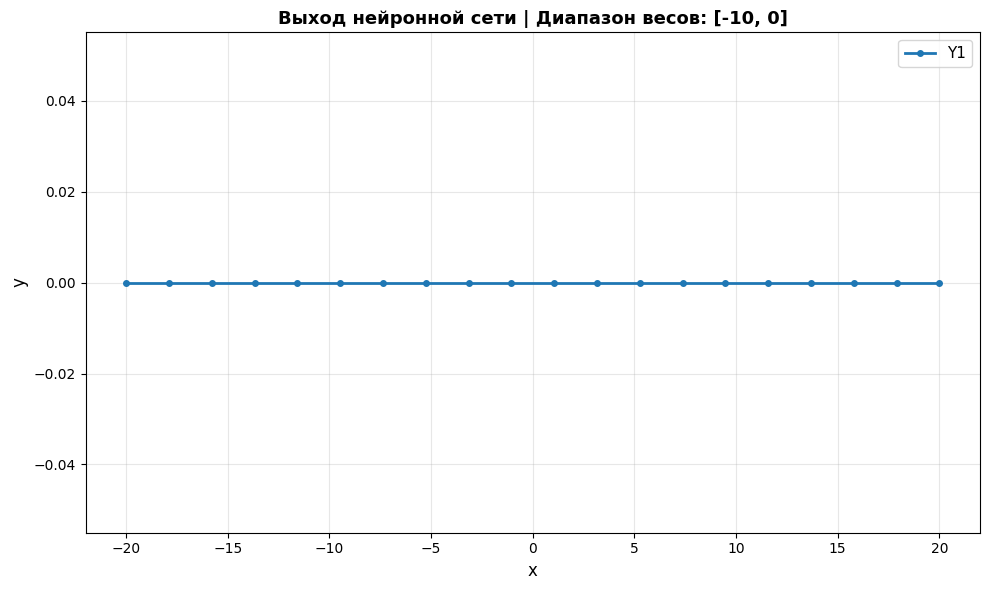

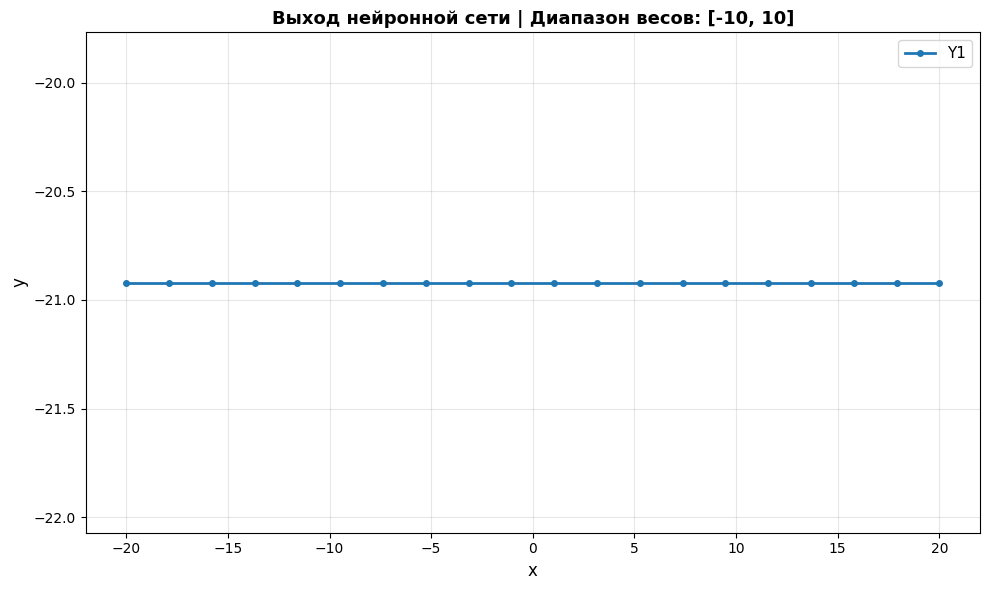

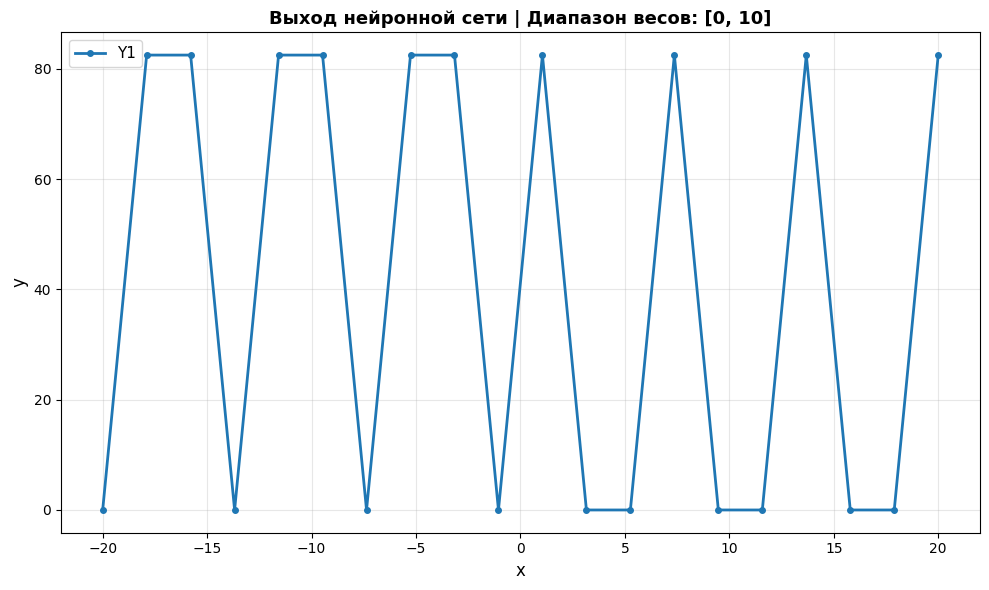

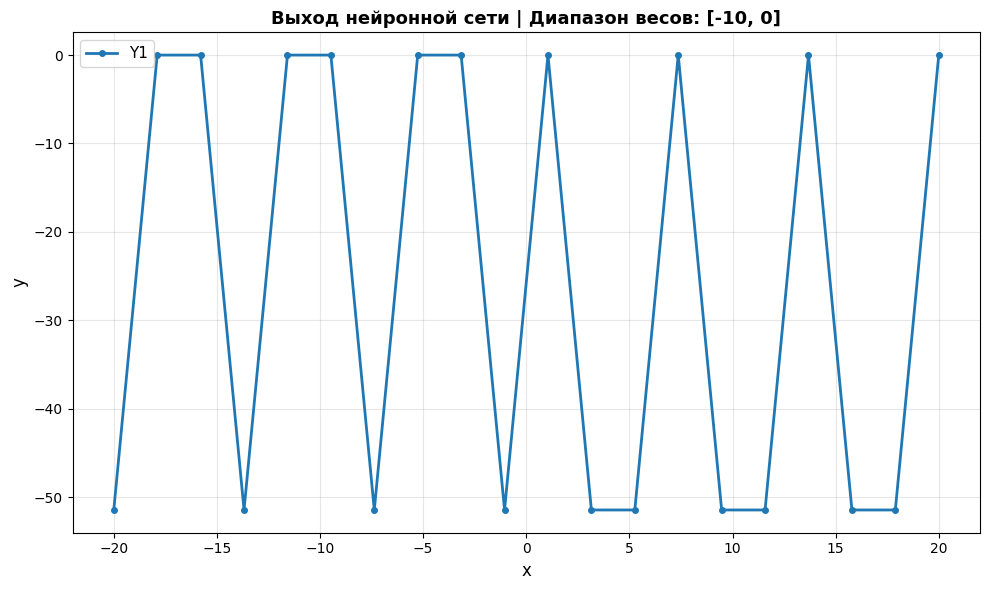

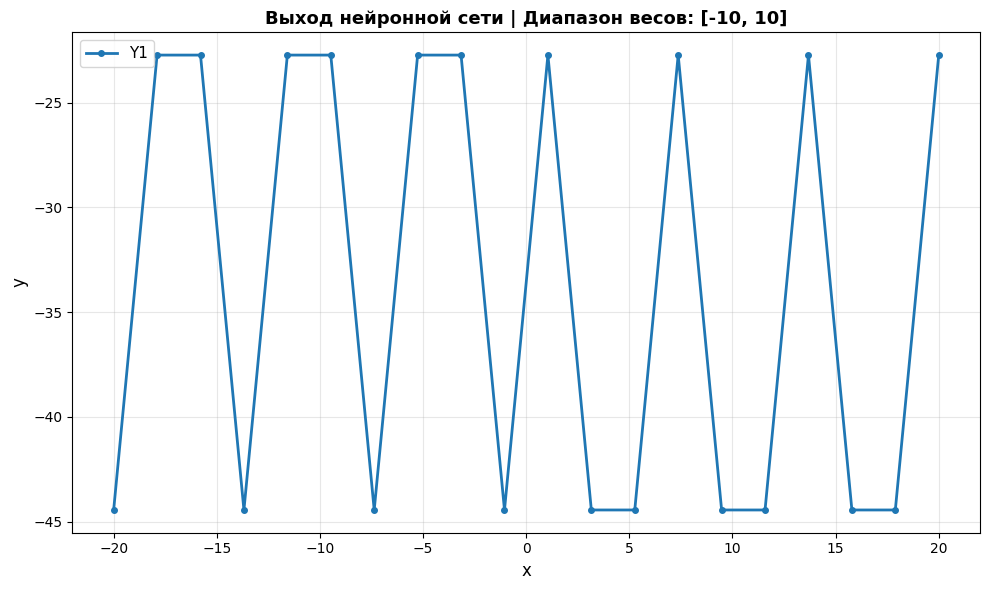

In [7]:
# Линейный сигнал
Wes(X_linear, vx, -10, 10)
plt.show()

# Пороговый сигнал
Wes(X_threshold, vx, -10, 10)
plt.show()

# Синусоидальный сигнал
Wes(X_sin, vx, -10, 10)
plt.show()

**Вывод:** увеличение весов выходного слоя может увеличить абсолютную величину выходного сигнала. Скрытый слой остаётся пороговым, поэтому форма реакции остаётся ступенчатой; большие входные веса сами по себе не делают переходы более резкими и при нулевом пороге не изменяют место переключения.

### 4. Общий вывод

В ходе лабораторной работы была реализована двухслойная нейронная сеть с одним входом, пятью скрытыми нейронами с пороговой функцией активации и одним выходным нейроном с линейной функцией. Были исследованы линейный, пороговый и синусоидальный входные сигналы, а также влияние положительных, отрицательных и смешанных весов. Пороговая функция преобразует сигналы скрытого слоя в 0 или 1, а веса выходного слоя определяют величину результирующего сигнала. В данной работе выполнялся прямой проход сети без обучения и изменения весов по ошибке.

### 5. Контрольные вопросы

**1. Понятие нейрона. Его математическая модель.**  
Искусственный нейрон — вычислительный элемент, который принимает входные сигналы, умножает их на веса, вычисляет взвешенную сумму и применяет функцию активации. Общая модель: $y=f(\sum_i w_ix_i+b)$.

**2. Нейронная сеть.**  
Нейронная сеть — совокупность связанных искусственных нейронов, предназначенная для обработки данных и выявления зависимостей.

**3. Свойства пороговой функции активации.**  
Пороговая функция сравнивает входное значение с порогом и выдаёт 1, если значение не меньше порога, и 0 в противном случае. Она проста, но имеет разрыв в точке порога и не является дифференцируемой в этой точке.

**4. Области применения нейронных сетей.**  
Распознавание изображений и речи, прогнозирование, анализ текстов, обнаружение закономерностей и поддержка принятия решений.

**5. Однослойные и многослойные нейронные сети.**  
Однослойная сеть не содержит скрытых слоёв. Многослойная сеть имеет один или несколько скрытых слоёв, которые позволяют преобразовывать входные данные на нескольких этапах.

**6. Линейность и нелинейность функций активации.**  
Линейная функция изменяет сигнал пропорционально входу. Нелинейные функции, например пороговая, позволяют сети формировать нелинейные преобразования и принимать решения по заданному порогу.